# ARTI406 - Machine Learning
# Assignment 2: Data Quality Assessment & Preprocessing

**Dataset:** LEGO Sets Dataset  
**Source:** [Kaggle - LEGO Sets](https://www.kaggle.com/datasets/mterzolo/lego-sets)  

---

In real-world machine learning projects, data is often:
- **Incomplete** (missing values)
- **Noisy** (outliers or random errors)
- **Inconsistent** (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

This assignment applies practical preprocessing techniques step by step on the **LEGO Sets Dataset**.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

## Load Dataset

In [2]:
df = pd.read_csv('lego_sets.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df[['set_name', 'ages', 'list_price', 'piece_count', 'num_reviews',
    'play_star_rating', 'star_rating', 'val_star_rating',
    'review_difficulty', 'theme_name', 'country']].head(10)

Dataset shape: (12261, 14)

Columns: ['ages', 'list_price', 'num_reviews', 'piece_count', 'play_star_rating', 'prod_desc', 'prod_id', 'prod_long_desc', 'review_difficulty', 'set_name', 'star_rating', 'theme_name', 'val_star_rating', 'country']


---
## Task 1: Identify Data Quality Issues

Data quality assessment is the first step before any preprocessing. We check:
- Data types of each column
- Missing values (null/NaN)
- Duplicate rows
- Statistical summary to spot anomalies

In [3]:
print('=== 1.1 Data Types ===')
print(df.dtypes)

=== 1.1 Data Types ===
ages                     str
list_price           float64
num_reviews          float64
piece_count          float64
play_star_rating     float64
prod_desc                str
prod_id              float64
prod_long_desc           str
review_difficulty        str
set_name                 str
star_rating          float64
theme_name               str
val_star_rating      float64
country                  str
dtype: object


In [4]:
print('=== 1.2 Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== 1.2 Missing Values ===
                   Missing Count  Missing %
num_reviews               1620      13.21
play_star_rating          1775      14.48
prod_desc                  377       3.07
review_difficulty         2055      16.76
star_rating               1620      13.21
theme_name                   3       0.02
val_star_rating           1795      14.64

Total missing values: 9245


In [5]:
print('=== 1.3 Duplicate Rows ===')
print(f'Number of duplicate rows: {df.duplicated().sum()}')

print('\n=== 1.4 Statistical Summary (Numerical Columns) ===')
numerical_cols = ['list_price', 'num_reviews', 'piece_count',
                  'play_star_rating', 'star_rating', 'val_star_rating']
print(df[numerical_cols].describe().round(2))

=== 1.3 Duplicate Rows ===
Number of duplicate rows: 1389

=== 1.4 Statistical Summary (Numerical Columns) ===
       list_price  num_reviews  piece_count  play_star_rating  star_rating  val_star_rating
count  12261.00     10641.00    12261.00      10486.00         10641.00      10466.00
mean      52.08        16.83      366.68          4.34             4.51          4.23
std       51.22        25.65      352.00          0.74             0.49          0.69
min        2.27         1.00        1.00          1.00             1.50          1.00
25%       19.99         3.00       97.00          4.00             4.50          4.00
50%       36.59         7.00      216.00          4.50             4.50          4.50
75%       70.19        16.83      544.00          5.00             5.00          4.50
max      519.99       393.00     7541.00          5.00             5.00          5.00


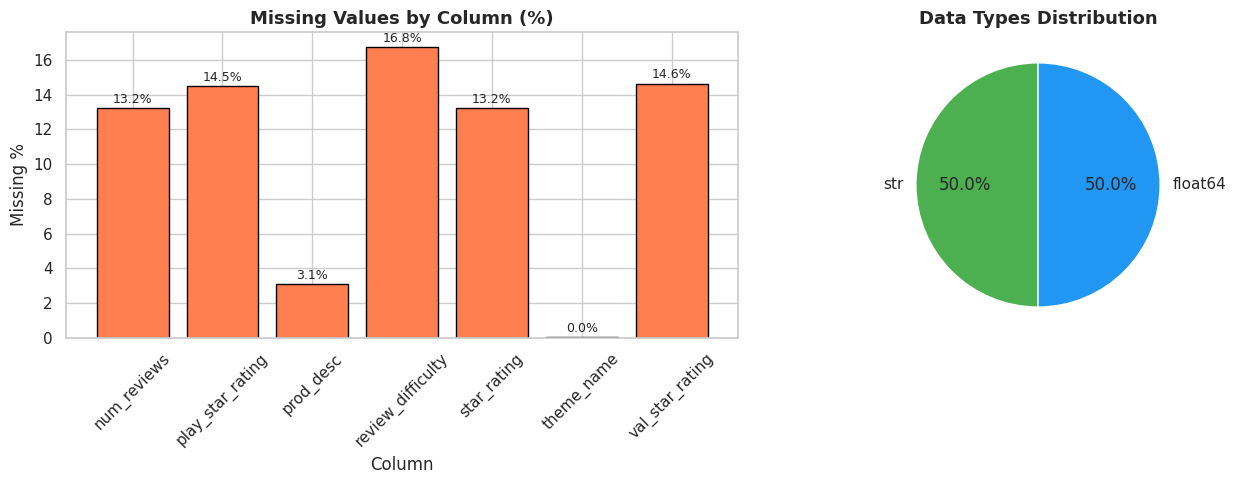

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values bar chart
missing_plot = missing_df[missing_df['Missing Count'] > 0]
axes[0].bar(missing_plot.index, missing_plot['Missing %'], color='coral', edgecolor='black')
axes[0].set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Missing %')
axes[0].tick_params(axis='x', rotation=45)

# Data types pie chart
dtype_counts = df.dtypes.astype(str).value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3', '#FF9800'], startangle=90)
axes[1].set_title('Data Types Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Task 1 - Observations:

| Issue | Details |
|---|---|
| **Missing Values** | 9,245 total missing values across 7 columns |
| **Most affected column** | `review_difficulty` with 2,055 missing (16.76%) |
| **Duplicate Rows** | 1,389 duplicate rows found |
| **Data Type Issues** | `ages` stored as string; `prod_id` should be integer |
| **Outlier Potential** | `list_price` max=519.99, `piece_count` max=7541, `num_reviews` max=393 |

These issues must be addressed before training any machine learning model.

---
## Task 2: Apply One Missing Value Strategy and Explain Why

**Strategy Chosen: Mean Imputation**

**Why Mean Imputation?**
- The missing columns (`num_reviews`, `star_rating`, `play_star_rating`, `val_star_rating`) are all **numerical rating/count columns**.
- Missing percentage ranges from ~13% to ~17% — moderate, not extreme.
- Mean imputation **preserves the overall distribution** and does not introduce extreme values.
- For rating columns (1–5 scale), filling with the mean keeps values within the valid range.
- Dropping rows would lose ~17% of data (2,055 rows), which is too much data loss.

In [7]:
numeric_missing = ['num_reviews', 'play_star_rating', 'star_rating', 'val_star_rating']

print('=== Missing Values BEFORE Imputation ===')
print(df[numeric_missing].isnull().sum())

# Apply Mean Imputation
df_clean = df.copy()
imputed_values = {}
for col in numeric_missing:
    mean_val = df_clean[col].mean()
    imputed_values[col] = round(mean_val, 4)
    df_clean[col] = df_clean[col].fillna(mean_val)

print('\n=== Mean Values Used for Imputation ===')
for col, val in imputed_values.items():
    print(f'  {col:<20} -> {val}')

# Handle categorical missing values
df_clean['review_difficulty'] = df_clean['review_difficulty'].fillna('Unknown')
df_clean['theme_name'] = df_clean['theme_name'].fillna('Unknown')
df_clean['prod_desc'] = df_clean['prod_desc'].fillna('No description')

print('\n=== Missing Values AFTER Imputation ===')
print(df_clean[numeric_missing].isnull().sum())
print(f'\nDataset is now complete: {df_clean.isnull().sum().sum() == 0}')

=== Missing Values BEFORE Imputation ===
num_reviews         1620
play_star_rating    1775
star_rating         1620
val_star_rating     1795
dtype: int64

=== Mean Values Used for Imputation ===
  num_reviews      -> 16.8262
  play_star_rating -> 4.3376
  star_rating      -> 4.5141
  val_star_rating  -> 4.229

=== Missing Values AFTER Imputation ===
num_reviews         0
play_star_rating    0
star_rating         0
val_star_rating     0
dtype: int64

Dataset is now complete: True


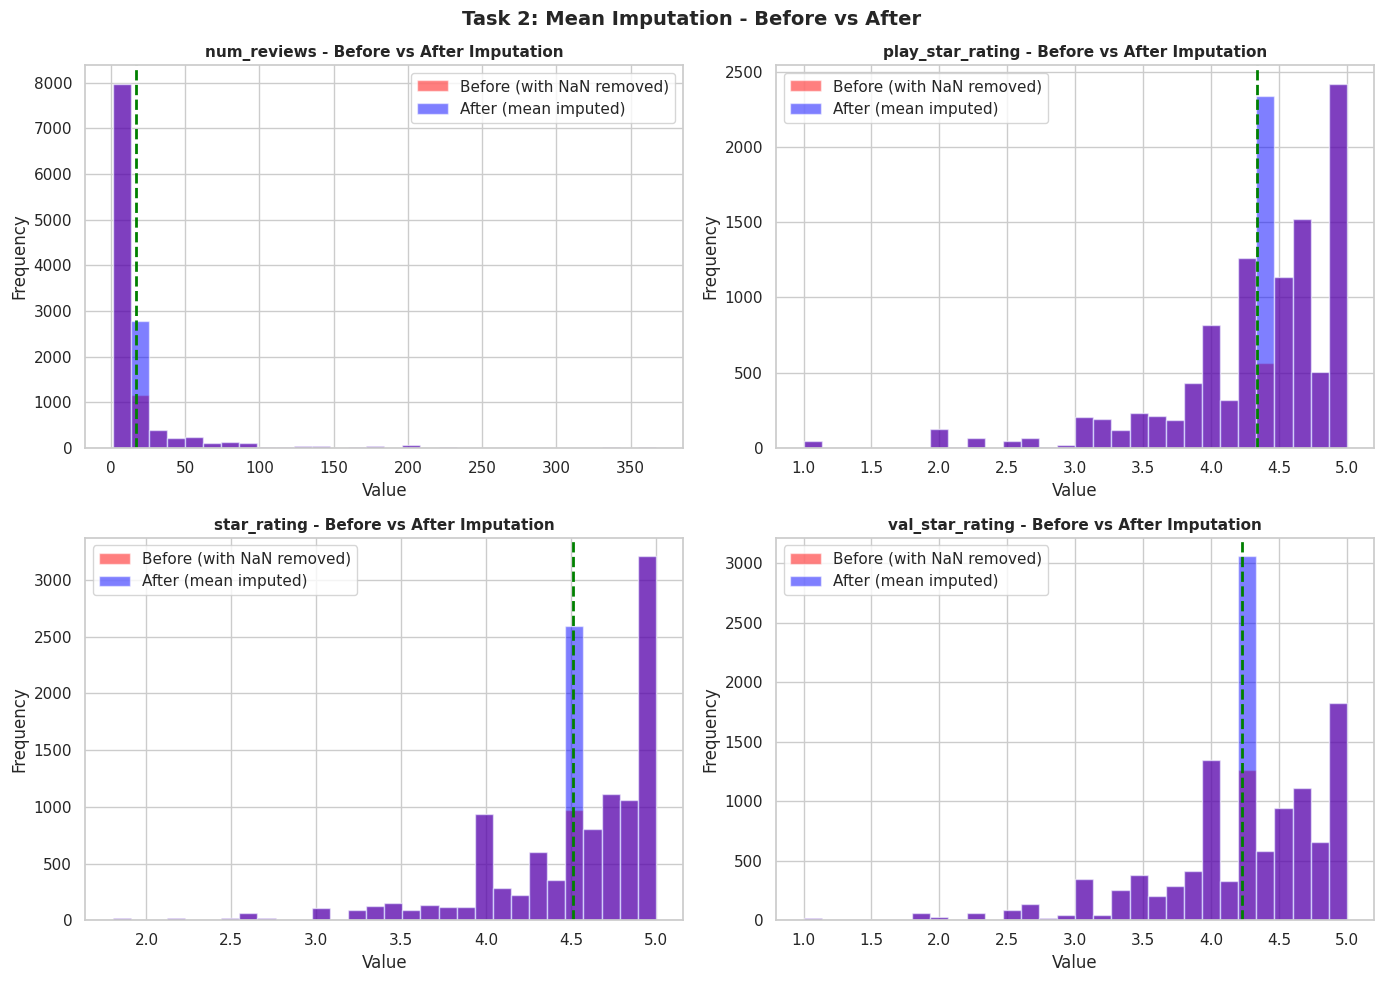

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_missing):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.5, color='red', label='Before (NaN removed)')
    axes[i].hist(df_clean[col], bins=30, alpha=0.5, color='blue', label='After (mean imputed)')
    axes[i].axvline(imputed_values[col], color='green', linestyle='--',
                    linewidth=2, label=f'Mean = {imputed_values[col]}')
    axes[i].set_title(f'{col} - Before vs After Imputation', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Task 2: Mean Imputation - Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3: Detect and Handle Outliers Using IQR

**IQR (Interquartile Range) Method:**
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Any value outside these bounds is considered an **outlier**.

**Handling Strategy: Capping (Winsorization)**  
Values below the lower bound are set to the lower bound, and values above the upper bound are set to the upper bound. This preserves all rows while removing extreme values.

In [9]:
outlier_cols = ['list_price', 'piece_count', 'num_reviews']

print('=== IQR Outlier Detection ===')
df_no_outliers = df_clean.copy()

for col in outlier_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_no_outliers[(df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)]
    print(f'\n{col}:')
    print(f'  Q1={Q1}, Q3={Q3}, IQR={round(IQR,2)}')
    print(f'  Lower Bound={round(lower,2)}, Upper Bound={round(upper,2)}')
    print(f'  Outliers: {len(outliers)} rows ({round(len(outliers)/len(df_no_outliers)*100,2)}%)')
    df_no_outliers[col] = df_no_outliers[col].clip(lower=max(0, lower), upper=upper)

print('\n=== Outliers Handled by Capping ===')
for col in outlier_cols:
    print(f'  {col:<12} -> capped to [0, {round(df_no_outliers[col].max(),2)}]')

=== IQR Outlier Detection ===

list_price:
  Q1=19.99, Q3=70.19, IQR=50.2
  Lower Bound=-55.31, Upper Bound=145.5
  Outliers: 1143 rows (9.32%)

piece_count:
  Q1=97.0, Q3=544.0, IQR=447.0
  Lower Bound=-573.5, Upper Bound=1214.5
  Outliers: 1034 rows (8.43%)

num_reviews:
  Q1=3.0, Q3=16.83, IQR=13.83
  Lower Bound=-17.74, Upper Bound=37.57
  Outliers: 1105 rows (9.01%)

=== Outliers Handled by Capping ===
  list_price  -> capped to [0, 145.5]
  piece_count -> capped to [0, 1214.5]
  num_reviews -> capped to [0, 37.57]


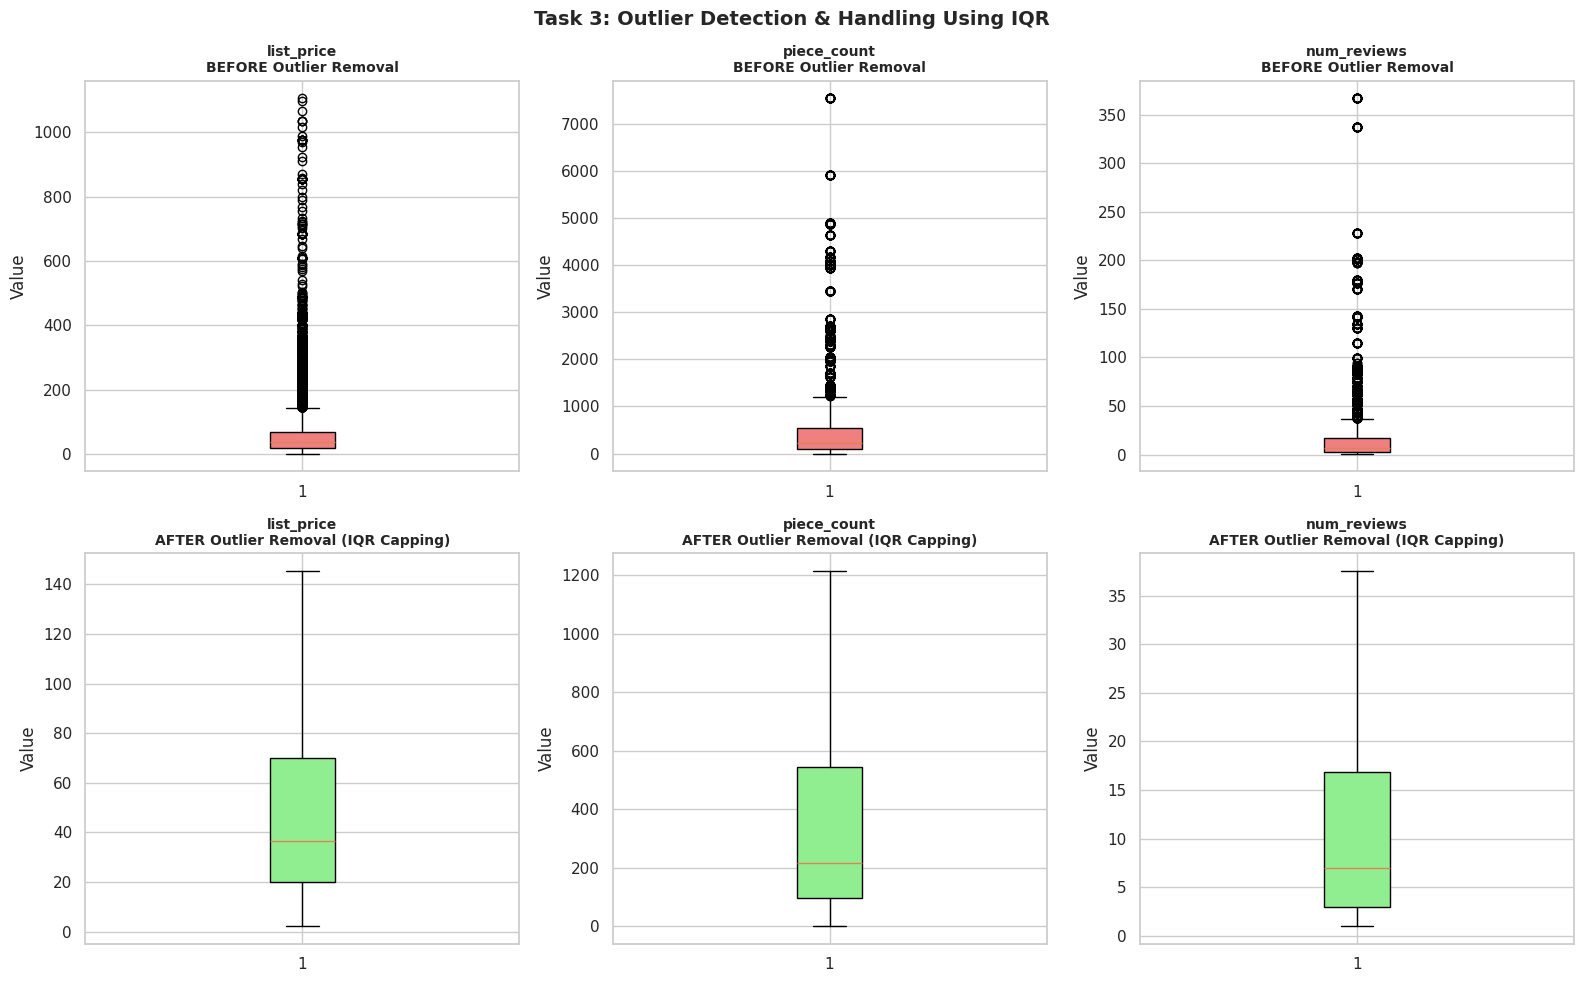

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(outlier_cols):
    axes[0, i].boxplot(df_clean[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightcoral'))
    axes[0, i].set_title(f'{col}\nBEFORE Outlier Removal', fontsize=10, fontweight='bold')

    axes[1, i].boxplot(df_no_outliers[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[1, i].set_title(f'{col}\nAFTER Outlier Removal (IQR Capping)', fontsize=10, fontweight='bold')

plt.suptitle('Task 3: Outlier Detection & Handling Using IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 4: Normalize Numerical Features Using Both Min-Max and Z-Score

**Min-Max Normalization:**  
Scales values to the range [0, 1]: `X_norm = (X - X_min) / (X_max - X_min)`

**Z-Score Normalization (Standardization):**  
Centers data around mean=0 with std=1: `X_std = (X - mean) / std`

In [11]:
norm_cols = ['list_price', 'piece_count', 'num_reviews']

print('=== Original Statistics ===')
print(df_no_outliers[norm_cols].describe().loc[['mean','std','min','max']].round(4))

# Min-Max Normalization
minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers.copy()
df_minmax[norm_cols] = minmax_scaler.fit_transform(df_no_outliers[norm_cols])

print('\n=== After Min-Max Normalization (range [0,1]) ===')
print(df_minmax[norm_cols].describe().loc[['mean','std','min','max']].round(4))

# Z-Score Normalization
zscore_scaler = StandardScaler()
df_zscore = df_no_outliers.copy()
df_zscore[norm_cols] = zscore_scaler.fit_transform(df_no_outliers[norm_cols])

print('\n=== After Z-Score Normalization (mean=0, std=1) ===')
print(df_zscore[norm_cols].describe().loc[['mean','std','min','max']].round(4))

=== Original Statistics ===
       list_price  piece_count  num_reviews
mean       52.0832     366.6820      11.4458
std        42.4349     367.8328      11.0179
min         2.2724       1.0000       1.0000
max       145.4955    1214.5000      37.5656

=== After Min-Max Normalization (range [0,1]) ===
       list_price  piece_count  num_reviews
mean       0.3478       0.3013       0.2857
std        0.2963       0.3031       0.3013
min        0.0000       0.0000       0.0000
max        1.0000       1.0000       1.0000

=== After Z-Score Normalization (mean=0, std=1) ===
       list_price  piece_count  num_reviews
mean      -0.0000      -0.0000      -0.0000
std        1.0000       1.0000       1.0000
min       -1.1739      -0.9942      -0.9481
max        2.2014       2.3050       2.3708


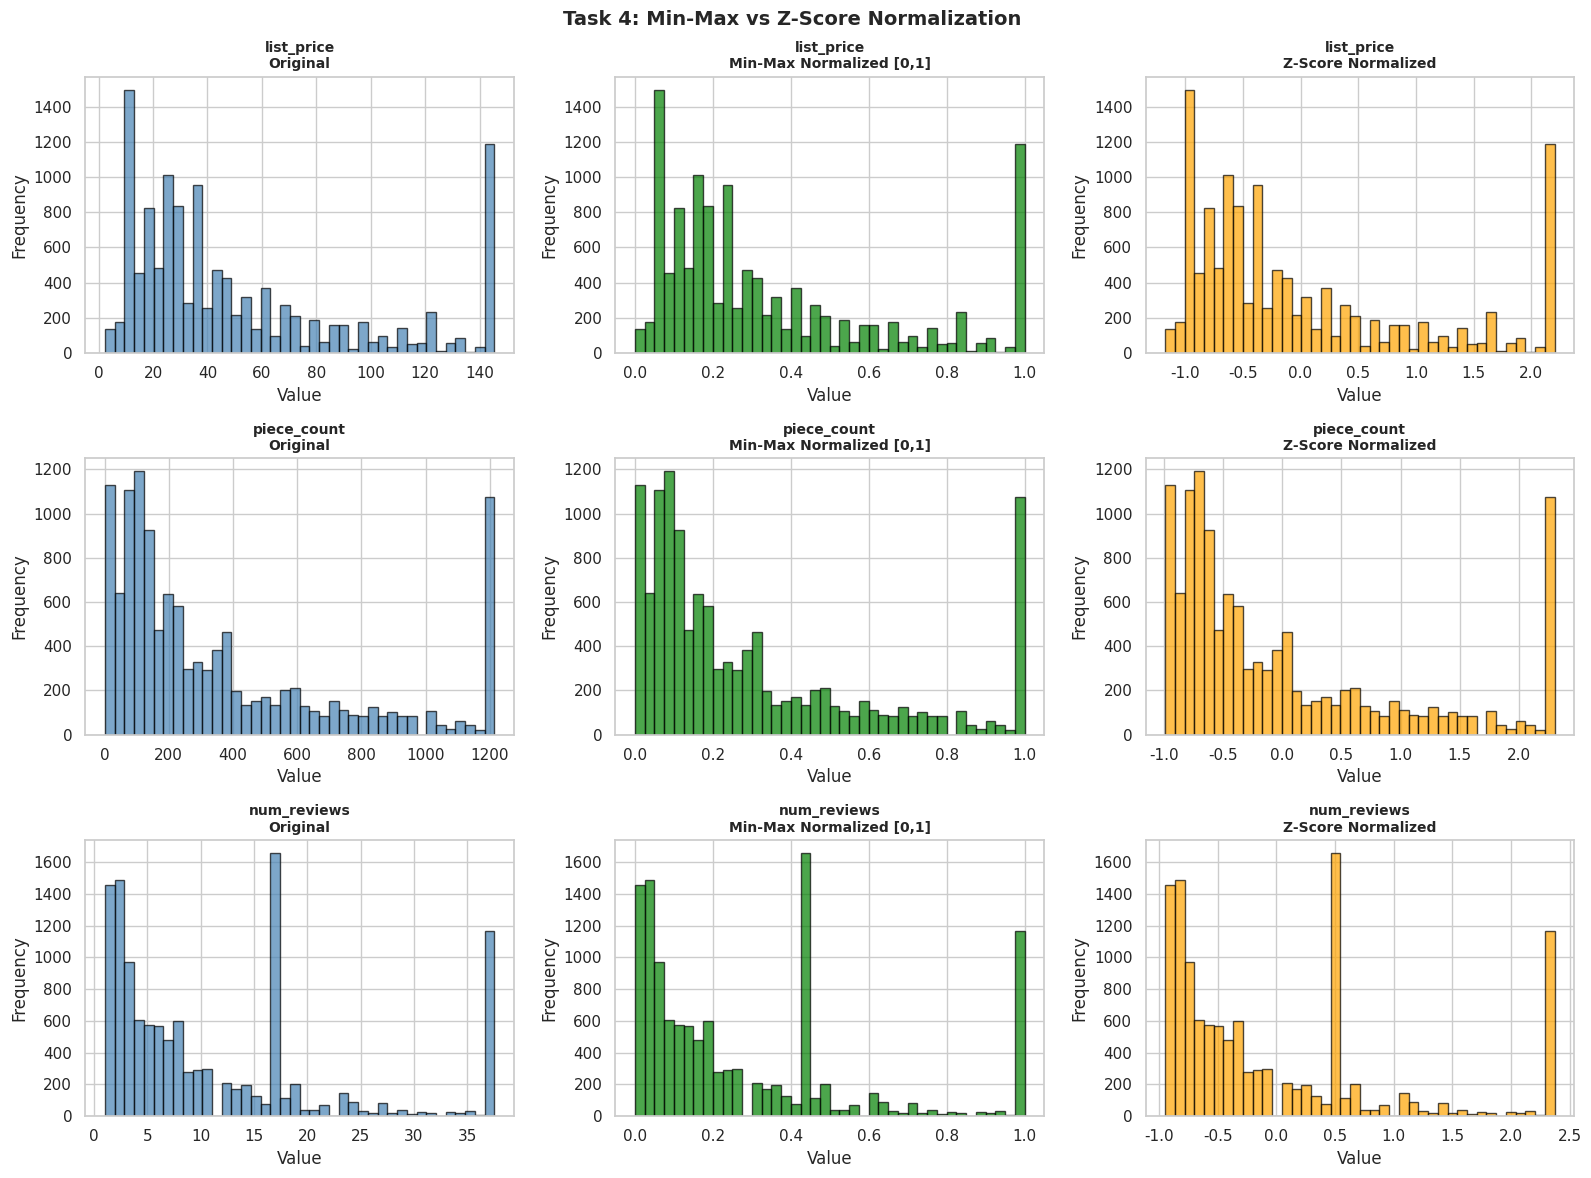

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, col in enumerate(norm_cols):
    axes[i, 0].hist(df_no_outliers[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{col}\nOriginal', fontsize=10, fontweight='bold')

    axes[i, 1].hist(df_minmax[col], bins=40, color='green', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'{col}\nMin-Max [0,1]', fontsize=10, fontweight='bold')

    axes[i, 2].hist(df_zscore[col], bins=40, color='orange', edgecolor='black', alpha=0.7)
    axes[i, 2].set_title(f'{col}\nZ-Score', fontsize=10, fontweight='bold')

plt.suptitle('Task 4: Min-Max vs Z-Score Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 4 - Comparison:

| Method | Range | Mean | Std | Best Used When |
|---|---|---|---|---|
| **Original** | 2.27 – 145.5 | 52.08 | 42.43 | Raw data |
| **Min-Max** | 0 – 1 | 0.35 | 0.30 | Neural networks, KNN |
| **Z-Score** | -1.17 – 2.20 | 0.00 | 1.00 | SVM, PCA, algorithms sensitive to scale |

---
## Task 5: Apply PCA and Interpret Explained Variance

**PCA (Principal Component Analysis)** reduces the dimensionality of data while retaining as much variance as possible.

We apply PCA on the 6 numerical features after Z-Score normalization:
`list_price`, `piece_count`, `num_reviews`, `play_star_rating`, `star_rating`, `val_star_rating`

In [13]:
pca_cols = ['list_price', 'piece_count', 'num_reviews',
            'play_star_rating', 'star_rating', 'val_star_rating']

# Use Z-score normalized data
zscore_all = StandardScaler()
X = pd.DataFrame(zscore_all.fit_transform(df_clean[pca_cols]), columns=pca_cols)
print(f'Data shape for PCA: {X.shape}')

# Apply PCA
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('\n=== Explained Variance per Component ===')
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'  PC{i+1}: {ev*100:5.2f}%  (Cumulative: {cv*100:.2f}%)')

n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'\nComponents needed for 80% variance: {n_80}')
print(f'Components needed for 95% variance: {n_95}')

Data shape for PCA: (12261, 6)

=== Explained Variance per Component ===
  PC1: 55.84%  (Cumulative: 55.84%)
  PC2: 19.42%  (Cumulative: 75.26%)
  PC3: 15.63%  (Cumulative: 90.89%)
  PC4:  5.23%  (Cumulative: 96.12%)
  PC5:  2.19%  (Cumulative: 98.30%)
  PC6:  1.70%  (Cumulative: 100.00%)

Components needed for 80% variance: 3
Components needed for 95% variance: 4


In [14]:
loadings_df = pd.DataFrame(
    pca.components_[:3],
    columns=pca_cols,
    index=[f'PC{i+1}' for i in range(3)]
)
print('=== PCA Component Loadings (PC1-PC3) ===')
print(loadings_df.round(4))

=== PCA Component Loadings (PC1-PC3) ===
     list_price  piece_count  num_reviews  play_star_rating  star_rating  val_star_rating
PC1      0.6310       0.6281       0.4550            0.0039      -0.0075          -0.0159
PC2     -0.1948      -0.2365       0.5782           -0.4609      -0.3902          -0.4551
PC3     -0.2528      -0.2223       0.6756            0.3531       0.3173           0.4526


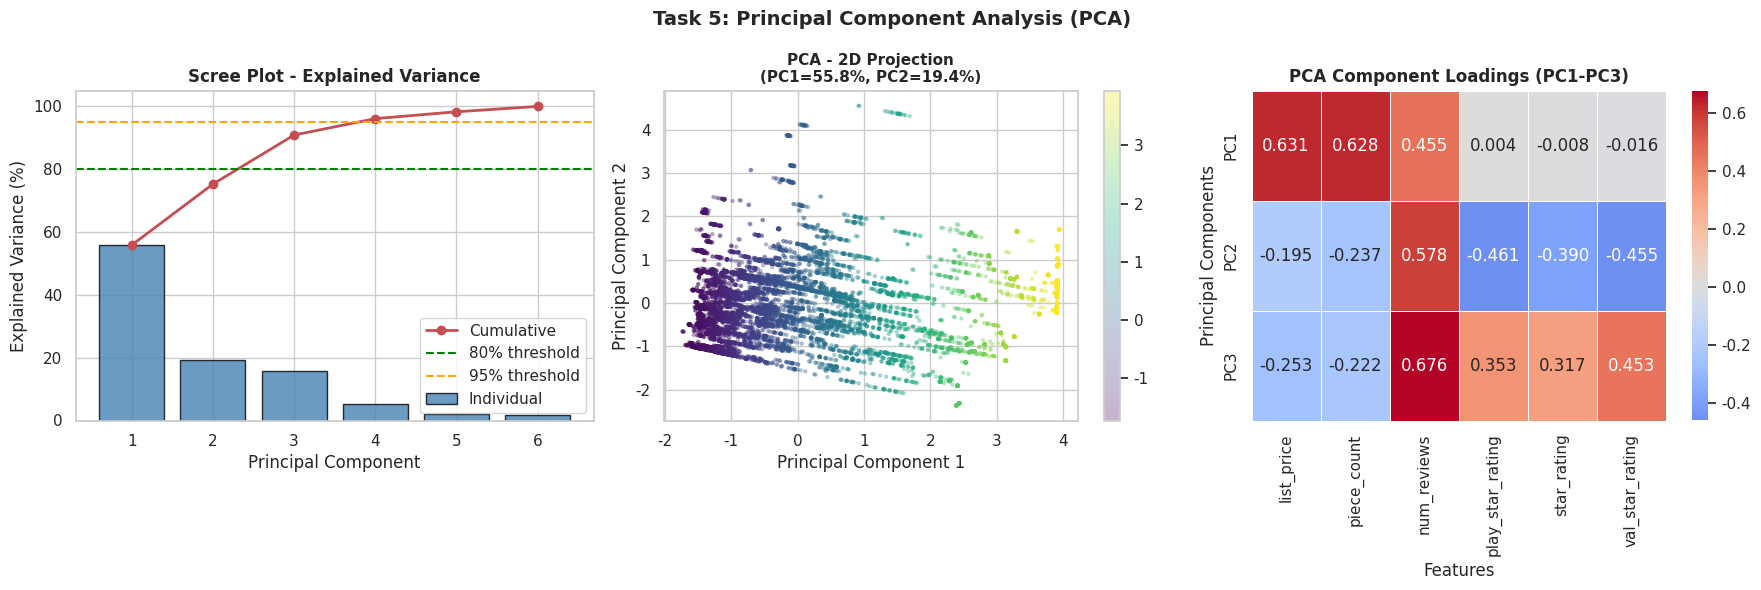

In [15]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scree plot
axes[0].bar(range(1, 7), explained_variance*100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, 7), cumulative_variance*100, 'ro-', linewidth=2, label='Cumulative')
axes[0].axhline(y=80, color='green', linestyle='--', label='80% threshold')
axes[0].axhline(y=95, color='orange', linestyle='--', label='95% threshold')
axes[0].set_title('Scree Plot - Explained Variance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].legend()

# 2D scatter
scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3,
                          c=X_pca_2d[:, 0], cmap='viridis', s=5)
axes[1].set_title(f'PCA 2D Projection\n(PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Loadings heatmap
sns.heatmap(loadings_df, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[2], linewidths=0.5)
axes[2].set_title('PCA Loadings Heatmap (PC1-PC3)', fontsize=12, fontweight='bold')

plt.suptitle('Task 5: Principal Component Analysis (PCA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 5 - PCA Interpretation:

| Component | Explained Variance | Cumulative | Main Features |
|---|---|---|---|
| **PC1** | 55.84% | 55.84% | `list_price` (0.63), `piece_count` (0.63), `num_reviews` (0.46) |
| **PC2** | 19.42% | 75.26% | `num_reviews` (0.58), `play_star_rating` (-0.46), `val_star_rating` (-0.46) |
| **PC3** | 15.63% | 90.89% | `num_reviews` (0.68), `val_star_rating` (0.45) |

**Key Insights:**
- **PC1** (55.84%) captures the **size and price** dimension — larger, more expensive sets with more reviews.
- **PC2** (19.42%) separates **review volume** from **customer satisfaction ratings**.
- **Only 3 components** are needed to explain **90.89%** of the total variance.
- **4 components** capture **96.12%** of variance — a significant dimensionality reduction from 6 to 4 features.

---
## Summary

| Task | Description | Result |
|---|---|---|
| **Task 1** | Data Quality Assessment | 9,245 missing values, 1,389 duplicates, data type issues identified |
| **Task 2** | Mean Imputation | All 4 numerical columns filled; dataset now 100% complete |
| **Task 3** | IQR Outlier Detection | ~9% outliers in price, piece count, and reviews; capped via Winsorization |
| **Task 4** | Normalization | Min-Max → [0,1]; Z-Score → mean=0, std=1 |
| **Task 5** | PCA | 3 components explain 90.89%; PC1 captures size/price dimension |